In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [2]:
# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()

mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for mouse, days in mouse_days.items():
    for day in days:

        # remove M22 
        if mouse == 22:
            continue

        [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day)
        _,_,_,_,_,clusters_VR = compute_vr_tcs(mouse, day)

        gcs = load_cluster_locations(clusters_VR, cells=gcs)
        ngs = load_cluster_locations(clusters_VR, cells=ngs)
        ns = load_cluster_locations(clusters_VR, cells=ns)
        sc = load_cluster_locations(clusters_VR, cells=sc)
        ngs_ns = load_cluster_locations(clusters_VR, cells=ngs_ns)
        all = load_cluster_locations(clusters_VR, cells=all)
        
        gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
        ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
        ns_ = pd.concat([ns_, ns], ignore_index=True)
        sc_ = pd.concat([sc_, sc], ignore_index=True)
        ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
        all_ = pd.concat([all_, all], ignore_index=True)

    print(f'there are this many cells at the moment, {len(all_)}')

optimal travel lag is 1.8518518518518547 cm based on kde of travel at max spatial information
using travel lag of 1.8518518518518547 cm
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1

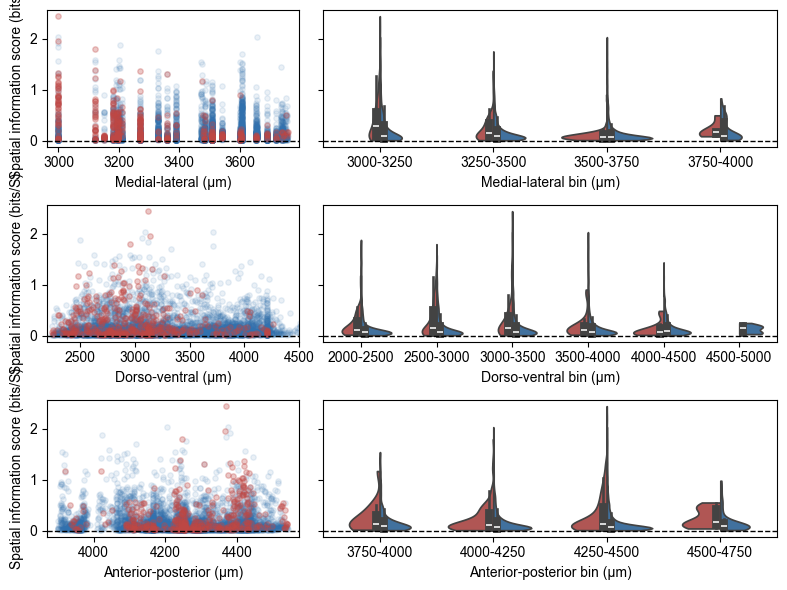

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]

# Helper function to get regular bins
def get_regular_bins(series, bin_size=250):
    min_val = int(np.floor(series.min() / bin_size) * bin_size)
    max_val = int(np.ceil(series.max() / bin_size) * bin_size)
    bins = np.arange(min_val, max_val + bin_size, bin_size)
    labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
    return bins, labels

# ML axis binning (250 um)
ml_series = pd.concat([(gcs_df['coord_SCs_x']*-1), (ngs_df['coord_SCs_x']*-1)])
ml_bins, ml_labels = get_regular_bins(ml_series, bin_size=250)
gcs_df['ml_bin'] = pd.cut(gcs_df['coord_SCs_x']*-1, bins=ml_bins, labels=ml_labels, include_lowest=True)
ngs_df['ml_bin'] = pd.cut(ngs_df['coord_SCs_x']*-1, bins=ml_bins, labels=ml_labels, include_lowest=True)

# DV axis binning (500 um)
dv_series = pd.concat([gcs_df['coord_SCs_y'], ngs_df['coord_SCs_y']])
dv_bins, dv_labels = get_regular_bins(dv_series, bin_size=500)
gcs_df['dv_bin'] = pd.cut(gcs_df['coord_SCs_y'], bins=dv_bins, labels=dv_labels, include_lowest=True)
ngs_df['dv_bin'] = pd.cut(ngs_df['coord_SCs_y'], bins=dv_bins, labels=dv_labels, include_lowest=True)

# AP axis binning (250 um)
ap_series = pd.concat([gcs_df['coord_SCs_z'], ngs_df['coord_SCs_z']])
ap_bins, ap_labels = get_regular_bins(ap_series, bin_size=250)
gcs_df['ap_bin'] = pd.cut(gcs_df['coord_SCs_z'], bins=ap_bins, labels=ap_labels, include_lowest=True)
ngs_df['ap_bin'] = pd.cut(ngs_df['coord_SCs_z'], bins=ap_bins, labels=ap_labels, include_lowest=True)

gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'

# Combine for violin plots
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

fig, axes = plt.subplots(3, 2, figsize=(8, 6), width_ratios=[1,1.8], sharey='row')

# ML scatter
axes[0, 0].scatter(ngs_df['coord_SCs_x']*-1, ngs_df['spatial_information_score'], color='#3171ae', alpha=0.1, s=15, label='NGS')
axes[0, 0].scatter(gcs_df['coord_SCs_x']*-1, gcs_df['spatial_information_score'], color='#c04744', alpha=0.3, s=15, label='GCS')
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_ylabel('Spatial information score (bits/S)')
axes[0, 0].set_xlabel('Medial-lateral (µm)')

# ML binned violin plot
sns.violinplot(
    data=combined, 
    x='ml_bin', 
    y='spatial_information_score', 
    hue='group', 
    split=True, 
    palette={'GCS': '#c04744', 'NGS': '#3171ae'}, 
    ax=axes[0, 1], 
    cut=0
)
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Medial-lateral bin (µm)')
axes[0, 1].get_legend().remove()  # Remove legend from violin plot

# DV scatter
axes[1, 0].scatter(ngs_df['coord_SCs_y'], ngs_df['spatial_information_score'], color='#3171ae', alpha=0.1, s=15, label='NGS')
axes[1, 0].scatter(gcs_df['coord_SCs_y'], gcs_df['spatial_information_score'], color='#c04744', alpha=0.3, s=15, label='GCS')
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_ylabel('Spatial information score (bits/S)')
axes[1, 0].set_xlabel('Dorso-ventral (µm)')
axes[1, 0].set_xlim(2200, 4500)

# DV binned violin plot
sns.violinplot(
    data=combined, 
    x='dv_bin', 
    y='spatial_information_score', 
    hue='group', 
    split=True, 
    palette={'GCS': '#c04744', 'NGS': '#3171ae'}, 
    ax=axes[1, 1], 
    cut=0
)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Dorso-ventral bin (µm)')
axes[1, 1].get_legend().remove()  # Remove legend from violin plot

# AP scatter
axes[2, 0].scatter(ngs_df['coord_SCs_z'], ngs_df['spatial_information_score'], color='#3171ae', alpha=0.1, s=15, label='NGS')
axes[2, 0].scatter(gcs_df['coord_SCs_z'], gcs_df['spatial_information_score'], color='#c04744', alpha=0.3, s=15, label='GCS')
axes[2, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2, 0].set_ylabel('Spatial information score (bits/S)')
axes[2, 0].set_xlabel('Anterior-posterior (µm)')

# AP binned violin plot
sns.violinplot(
    data=combined, 
    x='ap_bin', 
    y='spatial_information_score', 
    hue='group', 
    split=True,
    palette={'GCS': '#c04744', 'NGS': '#3171ae'}, 
    ax=axes[2, 1], 
    cut=0
)
axes[2, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2, 1].set_xlabel('Anterior-posterior bin (µm)')
axes[2, 1].set_ylabel('Spatial information score (bits/S)')
axes[2, 1].get_legend().remove()  # Remove legend from violin plot

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_by_anatomical_axis.pdf', bbox_inches='tight')
plt.show()

In [4]:
import pandas as pd
import statsmodels.formula.api as smf

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]

gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'

# Combine grid and non-grid cells for analysis
df = pd.concat([gcs_df, ngs_df], ignore_index=True)

# Make sure cluster_id and day are strings for variance components
df['cluster_id'] = df['cluster_id'].astype(str)
df['day'] = df['day'].astype(str)
df['mouse'] = df['mouse'].astype(str)

# Variance components for hierarchical random effects
vc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}

# ML axis (medial-lateral, use coord_SCs_x)
ml_df = df.dropna(subset=['coord_SCs_x'])
model_ml = smf.mixedlm(
    "spatial_information_score ~ group * coord_SCs_x",
    ml_df,
    groups=ml_df["mouse"],         # top-level random effect
    vc_formula=vc                  # nested random effects
)
result_ml = model_ml.fit()
print("ML axis model:")
print(result_ml.summary())

# DV axis (dorso-ventral, use coord_SCs_y)
dv_df = df.dropna(subset=['coord_SCs_y'])
model_dv = smf.mixedlm(
    "spatial_information_score ~ group * coord_SCs_y",
    dv_df,
    groups=dv_df["mouse"],
    vc_formula=vc
)
result_dv = model_dv.fit()
print("DV axis model:")
print(result_dv.summary())

# AP axis (anterior-posterior, use coord_SCs_z)
ap_df = df.dropna(subset=['coord_SCs_z'])
model_ap = smf.mixedlm(
    "spatial_information_score ~ group * coord_SCs_z",
    ap_df,
    groups=ap_df["mouse"],
    vc_formula=vc
)
result_ap = model_ap.fit()
print("AP axis model:")
print(result_ap.summary())

ML axis model:
                 Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: spatial_information_score
No. Observations: 5354    Method:             REML                     
No. Groups:       7       Scale:              0.0494                   
Min. group size:  263     Log-Likelihood:     349.3071                 
Max. group size:  1751    Converged:          Yes                      
Mean group size:  764.9                                                
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     2.435    0.197 12.336 0.000  2.048  2.821
group[T.NGS]                 -1.550    0.197 -7.870 0.000 -1.936 -1.164
coord_SCs_x                   0.001    0.000 11.004 0.000  0.001  0.001
group[T.NGS]:coord_SCs_x     -0.000    0.000 -7.479 0.000 -0.001 -

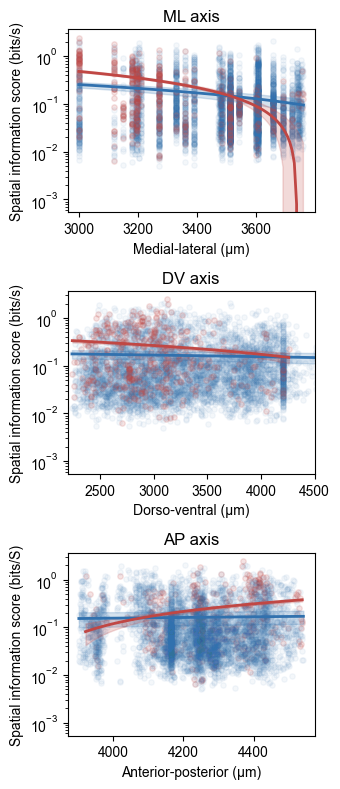

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]

gcs_df['group'] = 'GC'
ngs_df['group'] = 'NGS'

# Combine grid and non-grid cells for analysis
df = pd.concat([gcs_df, ngs_df], ignore_index=True)
df['cluster_id'] = df['cluster_id'].astype(str)
df['day'] = df['day'].astype(str)
df['mouse'] = df['mouse'].astype(str)

vc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}

# ML axis stats
ml_df = df.dropna(subset=['coord_SCs_x']).copy()
ml_df['ml_offset'] = ml_df['coord_SCs_x']*-1 - ((ml_df['coord_SCs_x']*-1).min())
model_ml = smf.mixedlm(
    "spatial_information_score ~ group * ml_offset",
    ml_df,
    groups=ml_df["mouse"],
    vc_formula=vc
)
result_ml = model_ml.fit()
ml_intercept = result_ml.params['Intercept']
ml_gcs_slope = result_ml.params['ml_offset']
ml_ngs_slope = result_ml.params['ml_offset'] + result_ml.params.get('group[T.NGS]:ml_offset', 0)
ml_ngs_intercept = ml_intercept + result_ml.params.get('group[T.NGS]', 0)

# DV axis stats
dv_df = df.dropna(subset=['coord_SCs_y']).copy()
dv_df['dv_offset'] = dv_df['coord_SCs_y'] - dv_df['coord_SCs_y'].min()
model_dv = smf.mixedlm(
    "spatial_information_score ~ group * dv_offset",
    dv_df,
    groups=dv_df["mouse"],
    vc_formula=vc
)
result_dv = model_dv.fit()
dv_intercept = result_dv.params['Intercept']
dv_gcs_slope = result_dv.params['dv_offset']
dv_ngs_slope = result_dv.params['dv_offset'] + result_dv.params.get('group[T.NGS]:dv_offset', 0)
dv_ngs_intercept = dv_intercept + result_dv.params.get('group[T.NGS]', 0)

# AP axis stats
ap_df = df.dropna(subset=['coord_SCs_z']).copy()
ap_df['ap_offset'] = ap_df['coord_SCs_z'] - ap_df['coord_SCs_z'].min()
model_ap = smf.mixedlm(
    "spatial_information_score ~ group * ap_offset",
    ap_df,
    groups=ap_df["mouse"],
    vc_formula=vc
)
result_ap = model_ap.fit()
ap_intercept = result_ap.params['Intercept']
ap_gcs_slope = result_ap.params['ap_offset']
ap_ngs_slope = result_ap.params['ap_offset'] + result_ap.params.get('group[T.NGS]:ap_offset', 0)
ap_ngs_intercept = ap_intercept + result_ap.params.get('group[T.NGS]', 0)

# --- Create 3 rows, 1 column plot: LMM fits with SEM and scatter points ---
fig, axes = plt.subplots(3, 1, figsize=(3.5, 8), sharex=False, sharey=True)

# ML axis: fit, SEM, and scatter
ml_gc = ml_df[ml_df['group'] == 'GC']
ml_ngs = ml_df[ml_df['group'] == 'NGS']

axes[0].scatter(ml_ngs['coord_SCs_x']*-1, ml_ngs['spatial_information_score'], color='#3171ae', alpha=0.05, s=15, label='NGS')
axes[0].scatter(ml_gc['coord_SCs_x']*-1, ml_gc['spatial_information_score'], color='#c04744', alpha=0.15, s=15, label='GC')

ml_x_gcs = np.linspace((ml_gc['coord_SCs_x']*-1).min(), (ml_gc['coord_SCs_x']*-1).max(), 100)
ml_x_ngs = np.linspace((ml_ngs['coord_SCs_x']*-1).min(), (ml_ngs['coord_SCs_x']*-1).max(), 100)
ml_x_gcs_offset = ml_x_gcs - ml_x_gcs.min()
ml_x_ngs_offset = ml_x_ngs - ml_x_ngs.min()

ml_gcs_pred = ml_intercept + ml_gcs_slope * ml_x_gcs_offset
ml_gcs_se = np.sqrt(
    result_ml.cov_params().loc['Intercept', 'Intercept'] +
    (ml_x_gcs_offset**2) * result_ml.cov_params().loc['ml_offset', 'ml_offset'] +
    2 * ml_x_gcs_offset * result_ml.cov_params().loc['Intercept', 'ml_offset']
)

ml_ngs_pred = ml_ngs_intercept + ml_ngs_slope * ml_x_ngs_offset
ml_ngs_se = np.sqrt(
    result_ml.cov_params().loc['Intercept', 'Intercept'] +
    result_ml.cov_params().loc['group[T.NGS]', 'group[T.NGS]'] +
    (ml_x_ngs_offset**2) * (
        result_ml.cov_params().loc['ml_offset', 'ml_offset'] +
        result_ml.cov_params().loc['group[T.NGS]:ml_offset', 'group[T.NGS]:ml_offset'] +
        2 * result_ml.cov_params().loc['ml_offset', 'group[T.NGS]:ml_offset']
    ) +
    2 * ml_x_ngs_offset * (
        result_ml.cov_params().loc['Intercept', 'ml_offset'] +
        result_ml.cov_params().loc['group[T.NGS]', 'ml_offset'] +
        result_ml.cov_params().loc['Intercept', 'group[T.NGS]:ml_offset'] +
        result_ml.cov_params().loc['group[T.NGS]', 'group[T.NGS]:ml_offset']
    )
)
axes[0].plot(ml_x_ngs, ml_ngs_pred, color='#3171ae', linewidth=2)
axes[0].fill_between(ml_x_ngs, ml_ngs_pred - ml_ngs_se, ml_ngs_pred + ml_ngs_se, color='#3171ae', alpha=0.2)

axes[0].plot(ml_x_gcs, ml_gcs_pred, color='#c04744', linewidth=2)
axes[0].fill_between(ml_x_gcs, ml_gcs_pred - ml_gcs_se, ml_gcs_pred + ml_gcs_se, color='#c04744', alpha=0.2)

axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Medial-lateral (µm)')
axes[0].set_ylabel('Spatial information score (bits/s)')
axes[0].set_title('ML axis')
axes[0].set_yscale('log')

# DV axis: fit, SEM, and scatter
dv_gc = dv_df[dv_df['group'] == 'GC']
dv_ngs = dv_df[dv_df['group'] == 'NGS']

axes[1].scatter(dv_ngs['coord_SCs_y'], dv_ngs['spatial_information_score'], color='#3171ae', alpha=0.05, s=15, label='NGS')
axes[1].scatter(dv_gc['coord_SCs_y'], dv_gc['spatial_information_score'], color='#c04744', alpha=0.15, s=15, label='GC')

dv_x_gcs = np.linspace(dv_gc['coord_SCs_y'].min(), dv_gc['coord_SCs_y'].max(), 100)
dv_x_ngs = np.linspace(dv_ngs['coord_SCs_y'].min(), dv_ngs['coord_SCs_y'].max(), 100)
dv_x_gcs_offset = dv_x_gcs - dv_x_gcs.min()
dv_x_ngs_offset = dv_x_ngs - dv_x_ngs.min()

dv_gcs_pred = dv_intercept + dv_gcs_slope * dv_x_gcs_offset
dv_gcs_se = np.sqrt(
    result_dv.cov_params().loc['Intercept', 'Intercept'] +
    (dv_x_gcs_offset**2) * result_dv.cov_params().loc['dv_offset', 'dv_offset'] +
    2 * dv_x_gcs_offset * result_dv.cov_params().loc['Intercept', 'dv_offset']
)

dv_ngs_pred = dv_ngs_intercept + dv_ngs_slope * dv_x_ngs_offset
dv_ngs_se = np.sqrt(
    result_dv.cov_params().loc['Intercept', 'Intercept'] +
    result_dv.cov_params().loc['group[T.NGS]', 'group[T.NGS]'] +
    (dv_x_ngs_offset**2) * (
        result_dv.cov_params().loc['dv_offset', 'dv_offset'] +
        result_dv.cov_params().loc['group[T.NGS]:dv_offset', 'group[T.NGS]:dv_offset'] +
        2 * result_dv.cov_params().loc['dv_offset', 'group[T.NGS]:dv_offset']
    ) +
    2 * dv_x_ngs_offset * (
        result_dv.cov_params().loc['Intercept', 'dv_offset'] +
        result_dv.cov_params().loc['group[T.NGS]', 'dv_offset'] +
        result_dv.cov_params().loc['Intercept', 'group[T.NGS]:dv_offset'] +
        result_dv.cov_params().loc['group[T.NGS]', 'group[T.NGS]:dv_offset']
    )
)
axes[1].plot(dv_x_ngs, dv_ngs_pred, color='#3171ae', linewidth=2)
axes[1].fill_between(dv_x_ngs, dv_ngs_pred - dv_ngs_se, dv_ngs_pred + dv_ngs_se, color='#3171ae', alpha=0.2)

axes[1].plot(dv_x_gcs, dv_gcs_pred, color='#c04744', linewidth=2)
axes[1].fill_between(dv_x_gcs, dv_gcs_pred - dv_gcs_se, dv_gcs_pred + dv_gcs_se, color='#c04744', alpha=0.2)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Dorso-ventral (µm)')
axes[1].set_title('DV axis')
axes[1].set_xlim(2200, 4500)
axes[1].set_ylabel('Spatial information score (bits/s)')
axes[1].set_yscale('log')

# AP axis: fit, SEM, and scatter
ap_gc = ap_df[ap_df['group'] == 'GC']
ap_ngs = ap_df[ap_df['group'] == 'NGS']

axes[2].scatter(ap_gc['coord_SCs_z'], ap_gc['spatial_information_score'], color='#c04744', alpha=0.15, s=15, label='GC')
axes[2].scatter(ap_ngs['coord_SCs_z'], ap_ngs['spatial_information_score'], color='#3171ae', alpha=0.05, s=15, label='NGS')

ap_x_gcs = np.linspace(ap_gc['coord_SCs_z'].min(), ap_gc['coord_SCs_z'].max(), 100)
ap_x_ngs = np.linspace(ap_ngs['coord_SCs_z'].min(), ap_ngs['coord_SCs_z'].max(), 100)
ap_x_gcs_offset = ap_x_gcs - ap_x_gcs.min()
ap_x_ngs_offset = ap_x_ngs - ap_x_ngs.min()

ap_ngs_pred = ap_ngs_intercept + ap_ngs_slope * ap_x_ngs_offset
ap_ngs_se = np.sqrt(
    result_ap.cov_params().loc['Intercept', 'Intercept'] +
    result_ap.cov_params().loc['group[T.NGS]', 'group[T.NGS]'] +
    (ap_x_ngs_offset**2) * (
        result_ap.cov_params().loc['ap_offset', 'ap_offset'] +
        result_ap.cov_params().loc['group[T.NGS]:ap_offset', 'group[T.NGS]:ap_offset'] +
        2 * result_ap.cov_params().loc['ap_offset', 'group[T.NGS]:ap_offset']
    ) +
    2 * ap_x_ngs_offset * (
        result_ap.cov_params().loc['Intercept', 'ap_offset'] +
        result_ap.cov_params().loc['group[T.NGS]', 'ap_offset'] +
        result_ap.cov_params().loc['Intercept', 'group[T.NGS]:ap_offset'] +
        result_ap.cov_params().loc['group[T.NGS]', 'group[T.NGS]:ap_offset']
    )
)

ap_gcs_pred = ap_intercept + ap_gcs_slope * ap_x_gcs_offset
ap_gcs_se = np.sqrt(
    result_ap.cov_params().loc['Intercept', 'Intercept'] +
    (ap_x_gcs_offset**2) * result_ap.cov_params().loc['ap_offset', 'ap_offset'] +
    2 * ap_x_gcs_offset * result_ap.cov_params().loc['Intercept', 'ap_offset']
)

axes[2].plot(ap_x_ngs, ap_ngs_pred, color='#3171ae', linewidth=2)
axes[2].fill_between(ap_x_ngs, ap_ngs_pred - ap_ngs_se, ap_ngs_pred + ap_ngs_se, color='#3171ae', alpha=0.2)

axes[2].plot(ap_x_gcs, ap_gcs_pred, color='#c04744', linewidth=2)
axes[2].fill_between(ap_x_gcs, ap_gcs_pred - ap_gcs_se, ap_gcs_pred + ap_gcs_se, color='#c04744', alpha=0.2)

axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('Anterior-posterior (µm)')
axes[2].set_title('AP axis')
axes[2].set_ylabel('Spatial information score (bits/S)')
axes[2].set_yscale('log')
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/spatial_info_by_anatomical_axis_LMMfit_SEM_scatter.pdf', bbox_inches='tight')
plt.show()

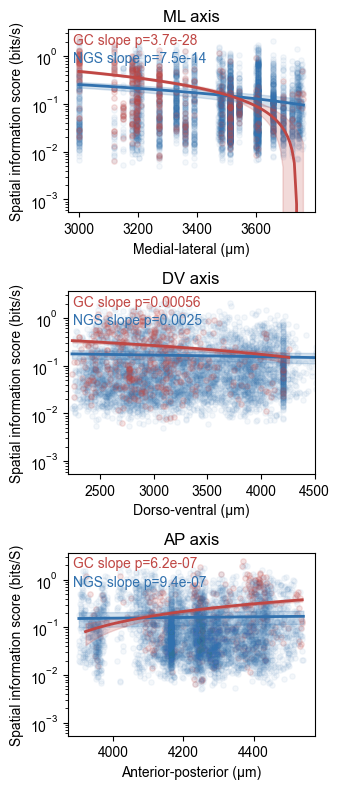

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]

gcs_df['group'] = 'GC'
ngs_df['group'] = 'NGS'

# Combine grid and non-grid cells for analysis
df = pd.concat([gcs_df, ngs_df], ignore_index=True)
df['cluster_id'] = df['cluster_id'].astype(str)
df['day'] = df['day'].astype(str)
df['mouse'] = df['mouse'].astype(str)

vc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}

# ML axis stats
ml_df = df.dropna(subset=['coord_SCs_x']).copy()
ml_df['ml_offset'] = ml_df['coord_SCs_x']*-1 - ((ml_df['coord_SCs_x']*-1).min())
model_ml = smf.mixedlm(
    "spatial_information_score ~ group * ml_offset",
    ml_df,
    groups=ml_df["mouse"],
    vc_formula=vc
)
result_ml = model_ml.fit()
ml_intercept = result_ml.params['Intercept']
ml_gcs_slope = result_ml.params['ml_offset']
ml_ngs_slope = result_ml.params['ml_offset'] + result_ml.params.get('group[T.NGS]:ml_offset', 0)
ml_ngs_intercept = ml_intercept + result_ml.params.get('group[T.NGS]', 0)
ml_gcs_p = result_ml.pvalues['ml_offset']
ml_ngs_p = result_ml.pvalues.get('group[T.NGS]:ml_offset', ml_gcs_p)

# DV axis stats
dv_df = df.dropna(subset=['coord_SCs_y']).copy()
dv_df['dv_offset'] = dv_df['coord_SCs_y'] - dv_df['coord_SCs_y'].min()
model_dv = smf.mixedlm(
    "spatial_information_score ~ group * dv_offset",
    dv_df,
    groups=dv_df["mouse"],
    vc_formula=vc
)
result_dv = model_dv.fit()
dv_intercept = result_dv.params['Intercept']
dv_gcs_slope = result_dv.params['dv_offset']
dv_ngs_slope = result_dv.params['dv_offset'] + result_dv.params.get('group[T.NGS]:dv_offset', 0)
dv_ngs_intercept = dv_intercept + result_dv.params.get('group[T.NGS]', 0)
dv_gcs_p = result_dv.pvalues['dv_offset']
dv_ngs_p = result_dv.pvalues.get('group[T.NGS]:dv_offset', dv_gcs_p)

# AP axis stats
ap_df = df.dropna(subset=['coord_SCs_z']).copy()
ap_df['ap_offset'] = ap_df['coord_SCs_z'] - ap_df['coord_SCs_z'].min()
model_ap = smf.mixedlm(
    "spatial_information_score ~ group * ap_offset",
    ap_df,
    groups=ap_df["mouse"],
    vc_formula=vc
)
result_ap = model_ap.fit()
ap_intercept = result_ap.params['Intercept']
ap_gcs_slope = result_ap.params['ap_offset']
ap_ngs_slope = result_ap.params['ap_offset'] + result_ap.params.get('group[T.NGS]:ap_offset', 0)
ap_ngs_intercept = ap_intercept + result_ap.params.get('group[T.NGS]', 0)
ap_gcs_p = result_ap.pvalues['ap_offset']
ap_ngs_p = result_ap.pvalues.get('group[T.NGS]:ap_offset', ap_gcs_p)

# --- Create 3 rows, 1 column plot: LMM fits with SEM and scatter points ---
fig, axes = plt.subplots(3, 1, figsize=(3.5, 8), sharex=False, sharey=True)

# ML axis: fit, SEM, and scatter
ml_gc = ml_df[ml_df['group'] == 'GC']
ml_ngs = ml_df[ml_df['group'] == 'NGS']

axes[0].scatter(ml_ngs['coord_SCs_x']*-1, ml_ngs['spatial_information_score'], color='#3171ae', alpha=0.05, s=15, label='NGS')
axes[0].scatter(ml_gc['coord_SCs_x']*-1, ml_gc['spatial_information_score'], color='#c04744', alpha=0.15, s=15, label='GC')

ml_x_gcs = np.linspace((ml_gc['coord_SCs_x']*-1).min(), (ml_gc['coord_SCs_x']*-1).max(), 100)
ml_x_ngs = np.linspace((ml_ngs['coord_SCs_x']*-1).min(), (ml_ngs['coord_SCs_x']*-1).max(), 100)
ml_x_gcs_offset = ml_x_gcs - ml_x_gcs.min()
ml_x_ngs_offset = ml_x_ngs - ml_x_ngs.min()

ml_gcs_pred = ml_intercept + ml_gcs_slope * ml_x_gcs_offset
ml_gcs_se = np.sqrt(
    result_ml.cov_params().loc['Intercept', 'Intercept'] +
    (ml_x_gcs_offset**2) * result_ml.cov_params().loc['ml_offset', 'ml_offset'] +
    2 * ml_x_gcs_offset * result_ml.cov_params().loc['Intercept', 'ml_offset']
)

ml_ngs_pred = ml_ngs_intercept + ml_ngs_slope * ml_x_ngs_offset
ml_ngs_se = np.sqrt(
    result_ml.cov_params().loc['Intercept', 'Intercept'] +
    result_ml.cov_params().loc['group[T.NGS]', 'group[T.NGS]'] +
    (ml_x_ngs_offset**2) * (
        result_ml.cov_params().loc['ml_offset', 'ml_offset'] +
        result_ml.cov_params().loc['group[T.NGS]:ml_offset', 'group[T.NGS]:ml_offset'] +
        2 * result_ml.cov_params().loc['ml_offset', 'group[T.NGS]:ml_offset']
    ) +
    2 * ml_x_ngs_offset * (
        result_ml.cov_params().loc['Intercept', 'ml_offset'] +
        result_ml.cov_params().loc['group[T.NGS]', 'ml_offset'] +
        result_ml.cov_params().loc['Intercept', 'group[T.NGS]:ml_offset'] +
        result_ml.cov_params().loc['group[T.NGS]', 'group[T.NGS]:ml_offset']
    )
)
axes[0].plot(ml_x_ngs, ml_ngs_pred, color='#3171ae', linewidth=2)
axes[0].fill_between(ml_x_ngs, ml_ngs_pred - ml_ngs_se, ml_ngs_pred + ml_ngs_se, color='#3171ae', alpha=0.2)

axes[0].plot(ml_x_gcs, ml_gcs_pred, color='#c04744', linewidth=2)
axes[0].fill_between(ml_x_gcs, ml_gcs_pred - ml_gcs_se, ml_gcs_pred + ml_gcs_se, color='#c04744', alpha=0.2)

axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Medial-lateral (µm)')
axes[0].set_ylabel('Spatial information score (bits/s)')
axes[0].set_title('ML axis')
#axes[0].set_yscale('log')

# Annotate significance for ML
axes[0].text(0.02, 0.98, f'GC slope p={ml_gcs_p:.2g}', color='#c04744', fontsize=10, transform=axes[0].transAxes, va='top')
axes[0].text(0.02, 0.88, f'NGS slope p={ml_ngs_p:.2g}', color='#3171ae', fontsize=10, transform=axes[0].transAxes, va='top')

# DV axis: fit, SEM, and scatter
dv_gc = dv_df[dv_df['group'] == 'GC']
dv_ngs = dv_df[dv_df['group'] == 'NGS']

axes[1].scatter(dv_ngs['coord_SCs_y'], dv_ngs['spatial_information_score'], color='#3171ae', alpha=0.05, s=15, label='NGS')
axes[1].scatter(dv_gc['coord_SCs_y'], dv_gc['spatial_information_score'], color='#c04744', alpha=0.15, s=15, label='GC')

dv_x_gcs = np.linspace(dv_gc['coord_SCs_y'].min(), dv_gc['coord_SCs_y'].max(), 100)
dv_x_ngs = np.linspace(dv_ngs['coord_SCs_y'].min(), dv_ngs['coord_SCs_y'].max(), 100)
dv_x_gcs_offset = dv_x_gcs - dv_x_gcs.min()
dv_x_ngs_offset = dv_x_ngs - dv_x_ngs.min()

dv_gcs_pred = dv_intercept + dv_gcs_slope * dv_x_gcs_offset
dv_gcs_se = np.sqrt(
    result_dv.cov_params().loc['Intercept', 'Intercept'] +
    (dv_x_gcs_offset**2) * result_dv.cov_params().loc['dv_offset', 'dv_offset'] +
    2 * dv_x_gcs_offset * result_dv.cov_params().loc['Intercept', 'dv_offset']
)

dv_ngs_pred = dv_ngs_intercept + dv_ngs_slope * dv_x_ngs_offset
dv_ngs_se = np.sqrt(
    result_dv.cov_params().loc['Intercept', 'Intercept'] +
    result_dv.cov_params().loc['group[T.NGS]', 'group[T.NGS]'] +
    (dv_x_ngs_offset**2) * (
        result_dv.cov_params().loc['dv_offset', 'dv_offset'] +
        result_dv.cov_params().loc['group[T.NGS]:dv_offset', 'group[T.NGS]:dv_offset'] +
        2 * result_dv.cov_params().loc['dv_offset', 'group[T.NGS]:dv_offset']
    ) +
    2 * dv_x_ngs_offset * (
        result_dv.cov_params().loc['Intercept', 'dv_offset'] +
        result_dv.cov_params().loc['group[T.NGS]', 'dv_offset'] +
        result_dv.cov_params().loc['Intercept', 'group[T.NGS]:dv_offset'] +
        result_dv.cov_params().loc['group[T.NGS]', 'group[T.NGS]:dv_offset']
    )
)
axes[1].plot(dv_x_ngs, dv_ngs_pred, color='#3171ae', linewidth=2)
axes[1].fill_between(dv_x_ngs, dv_ngs_pred - dv_ngs_se, dv_ngs_pred + dv_ngs_se, color='#3171ae', alpha=0.2)

axes[1].plot(dv_x_gcs, dv_gcs_pred, color='#c04744', linewidth=2)
axes[1].fill_between(dv_x_gcs, dv_gcs_pred - dv_gcs_se, dv_gcs_pred + dv_gcs_se, color='#c04744', alpha=0.2)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Dorso-ventral (µm)')
axes[1].set_title('DV axis')
axes[1].set_xlim(2200, 4500)
axes[1].set_ylabel('Spatial information score (bits/s)')
axes[1].set_yscale('log')

# Annotate significance for DV
axes[1].text(0.02, 0.98, f'GC slope p={dv_gcs_p:.2g}', color='#c04744', fontsize=10, transform=axes[1].transAxes, va='top')
axes[1].text(0.02, 0.88, f'NGS slope p={dv_ngs_p:.2g}', color='#3171ae', fontsize=10, transform=axes[1].transAxes, va='top')

# AP axis: fit, SEM, and scatter
ap_gc = ap_df[ap_df['group'] == 'GC']
ap_ngs = ap_df[ap_df['group'] == 'NGS']

axes[2].scatter(ap_gc['coord_SCs_z'], ap_gc['spatial_information_score'], color='#c04744', alpha=0.15, s=15, label='GC')
axes[2].scatter(ap_ngs['coord_SCs_z'], ap_ngs['spatial_information_score'], color='#3171ae', alpha=0.05, s=15, label='NGS')

ap_x_gcs = np.linspace(ap_gc['coord_SCs_z'].min(), ap_gc['coord_SCs_z'].max(), 100)
ap_x_ngs = np.linspace(ap_ngs['coord_SCs_z'].min(), ap_ngs['coord_SCs_z'].max(), 100)
ap_x_gcs_offset = ap_x_gcs - ap_x_gcs.min()
ap_x_ngs_offset = ap_x_ngs - ap_x_ngs.min()

ap_ngs_pred = ap_ngs_intercept + ap_ngs_slope * ap_x_ngs_offset
ap_ngs_se = np.sqrt(
    result_ap.cov_params().loc['Intercept', 'Intercept'] +
    result_ap.cov_params().loc['group[T.NGS]', 'group[T.NGS]'] +
    (ap_x_ngs_offset**2) * (
        result_ap.cov_params().loc['ap_offset', 'ap_offset'] +
        result_ap.cov_params().loc['group[T.NGS]:ap_offset', 'group[T.NGS]:ap_offset'] +
        2 * result_ap.cov_params().loc['ap_offset', 'group[T.NGS]:ap_offset']
    ) +
    2 * ap_x_ngs_offset * (
        result_ap.cov_params().loc['Intercept', 'ap_offset'] +
        result_ap.cov_params().loc['group[T.NGS]', 'ap_offset'] +
        result_ap.cov_params().loc['Intercept', 'group[T.NGS]:ap_offset'] +
        result_ap.cov_params().loc['group[T.NGS]', 'group[T.NGS]:ap_offset']
    )
)

ap_gcs_pred = ap_intercept + ap_gcs_slope * ap_x_gcs_offset
ap_gcs_se = np.sqrt(
    result_ap.cov_params().loc['Intercept', 'Intercept'] +
    (ap_x_gcs_offset**2) * result_ap.cov_params().loc['ap_offset', 'ap_offset'] +
    2 * ap_x_gcs_offset * result_ap.cov_params().loc['Intercept', 'ap_offset']
)

axes[2].plot(ap_x_ngs, ap_ngs_pred, color='#3171ae', linewidth=2)
axes[2].fill_between(ap_x_ngs, ap_ngs_pred - ap_ngs_se, ap_ngs_pred + ap_ngs_se, color='#3171ae', alpha=0.2)

axes[2].plot(ap_x_gcs, ap_gcs_pred, color='#c04744', linewidth=2)
axes[2].fill_between(ap_x_gcs, ap_gcs_pred - ap_gcs_se, ap_gcs_pred + ap_gcs_se, color='#c04744', alpha=0.2)

axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('Anterior-posterior (µm)')
axes[2].set_title('AP axis')
axes[2].set_ylabel('Spatial information score (bits/S)')
axes[2].set_yscale('log')

# Annotate significance for AP
axes[2].text(0.02, 0.98, f'GC slope p={ap_gcs_p:.2g}', color='#c04744', fontsize=10, transform=axes[2].transAxes, va='top')
axes[2].text(0.02, 0.88, f'NGS slope p={ap_ngs_p:.2g}', color='#3171ae', fontsize=10, transform=axes[2].transAxes, va='top')

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/spatial_info_by_anatomical_axis_LMMfit_SEM_scatter.pdf', bbox_inches='tight')
plt.show()

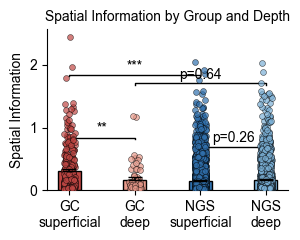

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Assign 'depth' column based on 'brain_region' (superficial/deep)
def assign_depth(region):
    if region in ['ENTm5', 'ENTm6']:
        return 'deep'
    elif region in ['ENTm1', 'ENTm2', 'ENTm3']:
        return 'superficial'
    else:
        return np.nan

df['depth'] = df['brain_region'].apply(assign_depth)
df = df[df['depth'].notna()]

df['group'] = df['group'].astype(str)
df['depth'] = df['depth'].astype(str)
df['mouse'] = df['mouse'].astype(str)
df['day'] = df['day'].astype(str)

# LMM for each group: spatial_information_score ~ depth, random effects: mouse, day
vc = {'day': '0 + C(day)'}
pvals = {}
for group in ['GC', 'NGS']:
    sub_df = df[df['group'] == group]
    model = smf.mixedlm(
        'spatial_information_score ~ depth',
        sub_df,
        groups=sub_df['mouse'],
        vc_formula=vc
    )
    result = model.fit()
    for param in result.pvalues.index:
        if param.startswith('depth'):
            pvals[group] = result.pvalues[param]
    if group not in pvals:
        pvals[group] = np.nan

# LMM for superficial GC vs NGS
sup_df = df[df['depth'] == 'superficial'].copy()
sup_df['group'] = sup_df['group'].astype(str)
model_sup = smf.mixedlm(
    'spatial_information_score ~ group',
    sup_df,
    groups=sup_df['mouse'],
    vc_formula=vc
)
result_sup = model_sup.fit()
pval_sup = np.nan
for param in result_sup.pvalues.index:
    if param.startswith('group'):
        pval_sup = result_sup.pvalues[param]

# LMM for deep GC vs NGS
deep_df = df[df['depth'] == 'deep'].copy()
deep_df['group'] = deep_df['group'].astype(str)
model_deep = smf.mixedlm(
    'spatial_information_score ~ group',
    deep_df,
    groups=deep_df['mouse'],
    vc_formula=vc
)
result_deep = model_deep.fit()
pval_deep = np.nan
for param in result_deep.pvalues.index:
    if param.startswith('group'):
        pval_deep = result_deep.pvalues[param]

# Set plotting order and custom colors
colors = {('GC', 'superficial'): '#c04744',
          ('GC', 'deep'): '#e89a8b',
          ('NGS', 'superficial'): '#3171ae',
          ('NGS', 'deep'): '#7bb0d6'}
depth_order = ['superficial', 'deep']
group_order = ['GC', 'NGS']

# Prepare data for plotting
plot_data = []
for group in group_order:
    for depth in depth_order:
        subset = df[(df['group'] == group) & (df['depth'] == depth)]
        mean = subset['spatial_information_score'].mean()
        sem = subset['spatial_information_score'].sem()
        plot_data.append({
            'group': group,
            'depth': depth,
            'mean': mean,
            'sem': sem,
            'values': subset['spatial_information_score'].values
        })

# Plot
fig, ax = plt.subplots(figsize=(3.2, 2.5))  # Smaller figure

bar_width = 0.35
x = np.arange(len(group_order) * len(depth_order))
bar_positions = []
labels = []
means = []
sems = []
all_points = []
bar_colors = []

for i, group in enumerate(group_order):
    for j, depth in enumerate(depth_order):
        idx = i * len(depth_order) + j
        bar_positions.append(idx)
        labels.append(f"{group}\n{depth}")
        means.append(plot_data[idx]['mean'])
        sems.append(plot_data[idx]['sem'])
        all_points.append(plot_data[idx]['values'])
        bar_colors.append(colors[(group, depth)])

# Plot bars (no error bars yet)
bars = ax.bar(bar_positions, means, color=bar_colors, edgecolor='k', width=bar_width, zorder=2)

# Overlay jittered points
for pos, values, c in zip(bar_positions, all_points, bar_colors):
    jitter = np.random.uniform(-bar_width/4, bar_width/4, size=len(values))
    ax.scatter(np.full_like(values, pos) + jitter, values, color=c, alpha=0.7, zorder=3, s=18, edgecolor='k', linewidth=0.4)

# Draw error bars at the top of each bar
for pos, mean, sem, color in zip(bar_positions, means, sems, bar_colors):
    ax.errorbar(pos, mean + sem, yerr=sem, fmt='none', ecolor='k', elinewidth=1.2, capsize=5, zorder=4)

# Annotate p-values for each group (between superficial and deep)
for i, group in enumerate(group_order):
    idx1 = i * 2
    idx2 = i * 2 + 1
    y_max = max(means[idx1] + sems[idx1], means[idx2] + sems[idx2])
    x1, x2 = bar_positions[idx1], bar_positions[idx2]
    # Start annotation higher above the bars
    y_line = y_max + 0.5
    y_text = y_line + 0.05
    ax.plot([x1, x1, x2, x2], [y_line, y_line+0.02, y_line+0.02, y_line], color='k', lw=1)
    pval = pvals[group]
    if pval < 0.001:
        ptext = '***'
    elif pval < 0.01:
        ptext = '**'
    elif pval < 0.05:
        ptext = '*'
    else:
        ptext = f"p={pval:.2g}"
    ax.text((x1 + x2) / 2, y_text, ptext, ha='center', va='bottom', fontsize=10)

# Annotate p-values for GC vs NGS at each depth
for j, (depth, pval) in enumerate(zip(depth_order, [pval_sup, pval_deep])):
    idx_gc = 0 + j  # GC superficial (0), GC deep (1)
    idx_ngs = 2 + j # NGS superficial (2), NGS deep (3)
    y_max = max(means[idx_gc] + sems[idx_gc], means[idx_ngs] + sems[idx_ngs])
    x1, x2 = bar_positions[idx_gc], bar_positions[idx_ngs]
    # Start annotation higher above the bars
    y_line = y_max + 1.5
    y_text = y_line + 0.05
    ax.plot([x1, x1, x2, x2], [y_line, y_line+0.02, y_line+0.02, y_line], color='k', lw=1)
    if pval < 0.001:
        ptext = '***'
    elif pval < 0.01:
        ptext = '**'
    elif pval < 0.05:
        ptext = '*'
    else:
        ptext = f"p={pval:.2g}"
    ax.text((x1 + x2) / 2, y_text, ptext, ha='center', va='bottom', fontsize=10)

ax.set_xticks(bar_positions)
ax.set_xticklabels(labels)
ax.set_ylabel('Spatial Information')
ax.set_title('Spatial Information by Group and Depth', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [10]:
gcs_df

,cluster_id,brain_region,grid_score,field_size,field_spacing,orientation,_smooth_sigma,travel,sig,null_grid_score,...,theta_index,firing_rate,firing_rate_OF1,firing_rate_VR,coord_SCs_x,coord_SCs_y,coord_SCs_z,coord_probe_x,coord_probe_y,group
0,412,ENTm5,0.440898,22.391733,29.855644,25.110225,1.5,2,True,None,...,0.029944,6.536149,6.936840,7.255499,-3655.888528,3741.751806,4201.968554,750.0,615.0,GC
1,220,ENTm3,0.339731,47.923674,63.898232,20.602474,1.5,3,True,None,...,0.036023,1.817727,3.331167,0.689566,-3510.000000,3300.592848,4246.023178,500.0,1035.0,GC
2,152,ENTm3,0.529560,25.805901,34.407868,29.303829,1.5,12,True,"[-0.0886751427729628, -0.1132305951940929, 0.0...",...,0.061667,1.420609,3.136529,0.854472,-3655.210179,4205.276034,4164.957340,750.0,150.0,GC
3,252,ENTm3,0.554809,47.255555,63.007406,1.410203,1.5,12,True,None,...,0.041887,9.383997,7.364530,10.899350,-3655.210179,4205.276034,4164.957340,750.0,150.0,GC
4,258,ENTm3,0.174685,33.450813,44.601084,0.169808,1.5,12,False,None,...,0.079080,11.643582,9.857306,13.145721,-3655.210179,4205.276034,4164.957340,750.0,150.0,GC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,377,ENTm3,1.088562,23.565777,31.421036,48.534811,1.5,7,True,None,...,0.053862,2.529340,4.163861,1.253893,-3270.000000,2849.071397,4245.445094,500.0,1155.0,GC
454,385,ENTm3,0.897253,23.654785,31.539713,52.234286,1.5,7,True,None,...,0.022141,6.946579,9.723439,4.376967,-3270.000000,2819.078481,4244.793221,532.0,1185.0,GC
455,387,ENTm3,0.514461,24.019471,32.025961,47.445769,1.5,7,True,None,...,0.048915,11.254542,15.057606,8.918107,-3270.000000,2789.085564,4244.141348,532.0,1215.0,GC
456,467,ENTm5,0.471324,59.589755,79.453007,39.275874,1.5,7,True,None,...,0.082861,6.577217,7.618219,5.400544,-3510.000000,2999.222941,4280.928054,782.0,990.0,GC


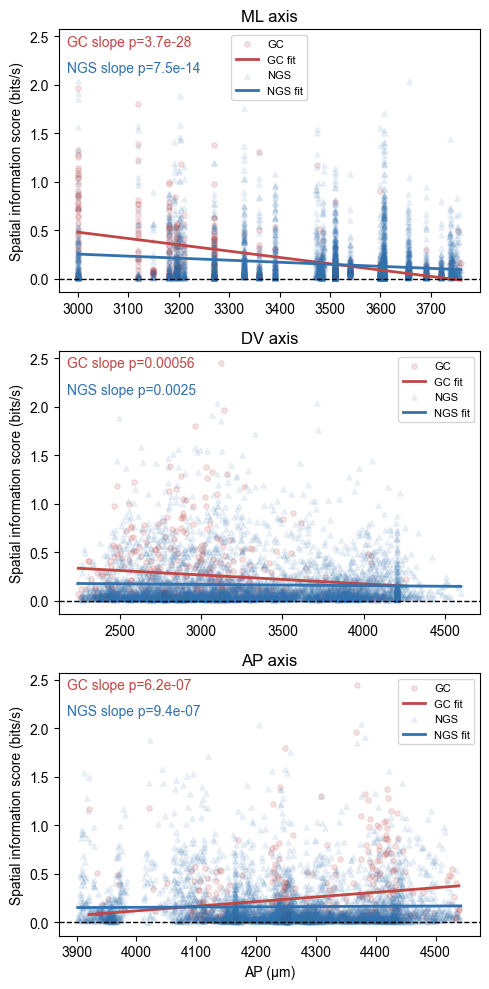

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]

gcs_df['group'] = 'GC'
ngs_df['group'] = 'NGS'

# Combine grid and non-grid cells for analysis
df = pd.concat([gcs_df, ngs_df], ignore_index=True)
df['cluster_id'] = df['cluster_id'].astype(str)
df['day'] = df['day'].astype(str)
df['mouse'] = df['mouse'].astype(str)

vc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}

# Fit LMMs for each axis (group * offset, no depth)
ml_df = df.dropna(subset=['coord_SCs_x']).copy()
ml_df['ml_offset'] = ml_df['coord_SCs_x']*-1 - ((ml_df['coord_SCs_x']*-1).min())
model_ml = smf.mixedlm(
    "spatial_information_score ~ group * ml_offset",
    ml_df,
    groups=ml_df["mouse"],
    vc_formula=vc
)
result_ml = model_ml.fit()

dv_df = df.dropna(subset=['coord_SCs_y']).copy()
dv_df['dv_offset'] = dv_df['coord_SCs_y'] - dv_df['coord_SCs_y'].min()
model_dv = smf.mixedlm(
    "spatial_information_score ~ group * dv_offset",
    dv_df,
    groups=dv_df["mouse"],
    vc_formula=vc
)
result_dv = model_dv.fit()

ap_df = df.dropna(subset=['coord_SCs_z']).copy()
ap_df['ap_offset'] = ap_df['coord_SCs_z'] - ap_df['coord_SCs_z'].min()
model_ap = smf.mixedlm(
    "spatial_information_score ~ group * ap_offset",
    ap_df,
    groups=ap_df["mouse"],
    vc_formula=vc
)
result_ap = model_ap.fit()

# --- Plotting: 3 rows (axes), 1 column, overlaying GC and NGS ---
fig, axes = plt.subplots(3, 1, figsize=(5, 10), sharex=False, sharey=True)
colors = {'GC': '#c04744', 'NGS': '#3171ae'}
markers = {'GC': 'o', 'NGS': '^'}

for i, (axis, offset, result, label) in enumerate([
    ('coord_SCs_x', 'ml_offset', result_ml, 'ML axis'),
    ('coord_SCs_y', 'dv_offset', result_dv, 'DV axis'),
    ('coord_SCs_z', 'ap_offset', result_ap, 'AP axis')
]):
    ax = axes[i]
    for group in ['GC', 'NGS']:
        group_df = df[df['group'] == group].dropna(subset=[axis])
        if group_df.empty:
            continue
        x = group_df[axis]*(-1 if axis == 'coord_SCs_x' else 1)
        y = group_df['spatial_information_score']
        ax.scatter(x, y, color=colors[group], alpha=0.08 if group == 'NGS' else 0.15, s=15, marker=markers[group], label=group)
        # Fit line for this group
        x_pred = np.linspace(x.min(), x.max(), 100)
        offset_pred = x_pred - x_pred.min()
        pred_df = pd.DataFrame({
            offset: offset_pred,
            'group': group
        })
        # Add interaction columns as needed for prediction
        for col in result.model.exog_names:
            if col not in pred_df.columns and ':' in col:
                pred_df[col] = 0
        pred_vals = result.predict(pred_df)
        ax.plot(x_pred, pred_vals, color=colors[group], linewidth=2, label=f'{group} fit')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    #ax.set_yscale('log')
    ax.set_title(label)
    if i == 2:
        ax.set_xlabel(f"{label.split()[0]} (µm)")
    ax.set_ylabel('Spatial information score (bits/s)')
    # Annotate p-values for the main effect of offset for each group
    for group in ['GC', 'NGS']:
        if group == 'GC':
            p_key = f'{offset}'
        else:
            p_key = f'group[T.NGS]:{offset}'
        pval = result.pvalues.get(p_key, np.nan)
        y_pos = 0.98 if group == 'GC' else 0.88
        ax.text(0.02, y_pos, f'{group} slope p={pval:.2g}', color=colors[group], fontsize=10, transform=ax.transAxes, va='top')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/spatial_info_by_anatomical_axis_LMMfit_SEM_scatter_by_group.pdf', bbox_inches='tight')
plt.show()

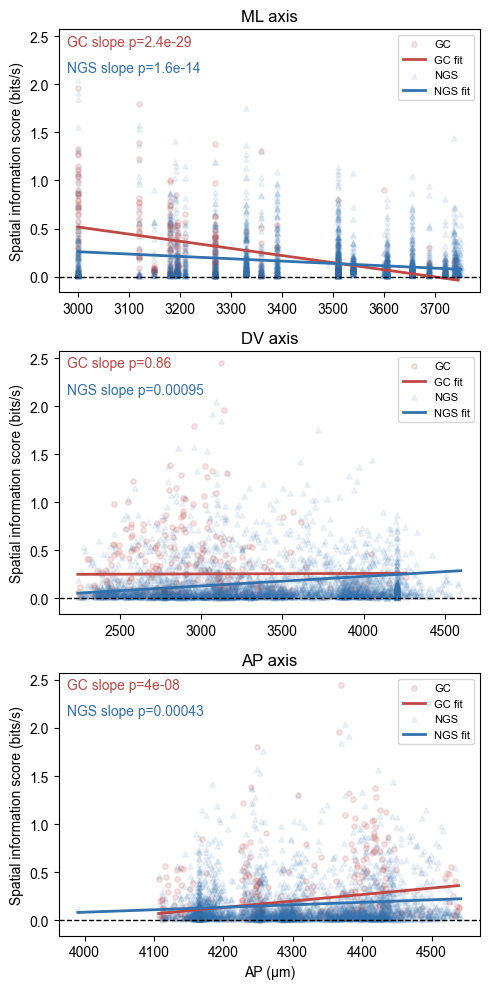

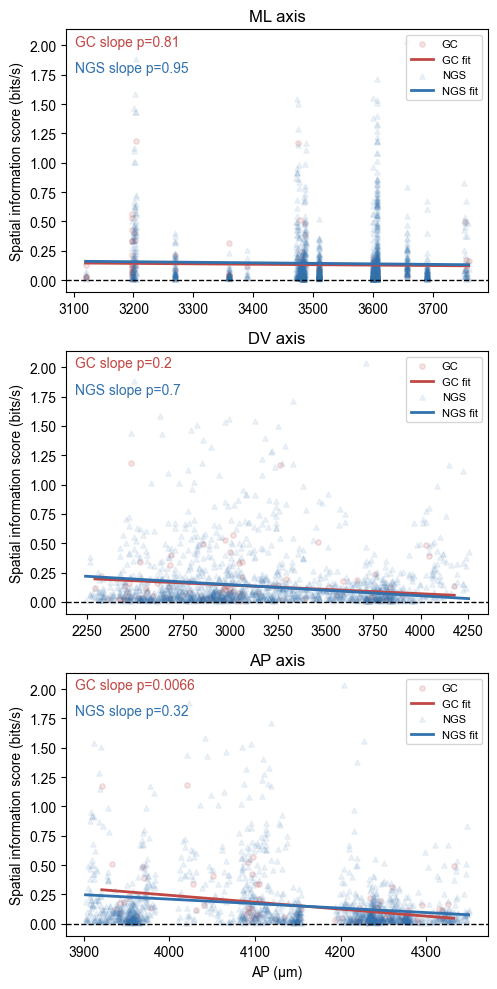

In [35]:
# --- LMM fits and plots for superficial and deep cells (side by side) ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Helper function to run LMM and plot for a given depth
def lmm_and_plot_by_depth(depth_label, outpath):
    gcs_df = gcs_.copy()
    gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
    gcs_df['group'] = 'GC'
    ngs_df = ngs_.copy()
    ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]
    ngs_df['group'] = 'NGS'
    
    df = pd.concat([gcs_df, ngs_df], ignore_index=True)
    df['cluster_id'] = df['cluster_id'].astype(str)
    df['day'] = df['day'].astype(str)
    df['mouse'] = df['mouse'].astype(str)
    
    def assign_depth(region):
        if region in ['ENTm5', 'ENTm6']:
            return 'deep'
        elif region in ['ENTm1', 'ENTm2', 'ENTm3']:
            return 'superficial'
        else:
            return np.nan

    df['depth'] = df['brain_region'].apply(assign_depth)
    df = df[df['depth'].notna()]
    df = df[df['depth'] == depth_label]
    
    vc = {
        "day": "0 + C(day)",
        "cluster": "0 + C(cluster_id)"
    }
    # Fit LMMs for each axis (group * offset)
    ml_df = df.dropna(subset=['coord_SCs_x']).copy()
    ml_df['ml_offset'] = ml_df['coord_SCs_x']*-1 - ((ml_df['coord_SCs_x']*-1).min())
    model_ml = smf.mixedlm(
        "spatial_information_score ~ group * ml_offset",
        ml_df,
        groups=ml_df["mouse"],
        vc_formula=vc
    )
    result_ml = model_ml.fit()
    dv_df = df.dropna(subset=['coord_SCs_y']).copy()
    dv_df['dv_offset'] = dv_df['coord_SCs_y'] - dv_df['coord_SCs_y'].min()
    model_dv = smf.mixedlm(
        "spatial_information_score ~ group * dv_offset",
        dv_df,
        groups=dv_df["mouse"],
        vc_formula=vc
    )
    result_dv = model_dv.fit()
    ap_df = df.dropna(subset=['coord_SCs_z']).copy()
    ap_df['ap_offset'] = ap_df['coord_SCs_z'] - ap_df['coord_SCs_z'].min()
    model_ap = smf.mixedlm(
        "spatial_information_score ~ group * ap_offset",
        ap_df,
        groups=ap_df["mouse"],
        vc_formula=vc
    )
    result_ap = model_ap.fit()
    # --- Plotting: 3 rows (axes), 1 column, overlaying GC and NGS ---
    fig, axes = plt.subplots(3, 1, figsize=(5, 10), sharex=False, sharey=True)
    colors = {'GC': '#c04744', 'NGS': '#3171ae'}
    markers = {'GC': 'o', 'NGS': '^'}
    for i, (axis, offset, result, label) in enumerate([
        ('coord_SCs_x', 'ml_offset', result_ml, 'ML axis'),
        ('coord_SCs_y', 'dv_offset', result_dv, 'DV axis'),
        ('coord_SCs_z', 'ap_offset', result_ap, 'AP axis')
    ]):
        ax = axes[i]
        for group in ['GC', 'NGS']:
            group_df = df[df['group'] == group].dropna(subset=[axis])
            if group_df.empty:
                continue
            x = group_df[axis]*(-1 if axis == 'coord_SCs_x' else 1)
            y = group_df['spatial_information_score']
            ax.scatter(x, y, color=colors[group], alpha=0.08 if group == 'NGS' else 0.15, s=15, marker=markers[group], label=group)
            # Fit line for this group
            x_pred = np.linspace(x.min(), x.max(), 100)
            offset_pred = x_pred - x_pred.min()
            pred_df = pd.DataFrame({
                offset: offset_pred,
                'group': group
            })
            # Add interaction columns as needed for prediction
            for col in result.model.exog_names:
                if col not in pred_df.columns and ':' in col:
                    pred_df[col] = 0
            pred_vals = result.predict(pred_df)
            ax.plot(x_pred, pred_vals, color=colors[group], linewidth=2, label=f'{group} fit')
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(label)
        if i == 2:
            ax.set_xlabel(f"{label.split()[0]} (µm)")
        ax.set_ylabel('Spatial information score (bits/s)')
        # Annotate p-values for the main effect of offset for each group
        for group in ['GC', 'NGS']:
            if group == 'GC':
                p_key = f'{offset}'
            else:
                p_key = f'group[T.NGS]:{offset}'
            pval = result.pvalues.get(p_key, np.nan)
            y_pos = 0.98 if group == 'GC' else 0.88
            ax.text(0.02, y_pos, f'{group} slope p={pval:.2g}', color=colors[group], fontsize=10, transform=ax.transAxes, va='top')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(outpath, bbox_inches='tight')
    plt.show()

# Run for superficial
lmm_and_plot_by_depth('superficial', '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/spatial_info_by_anatomical_axis_LMMfit_SEM_scatter_by_group_superficial.pdf')
# Run for deep
lmm_and_plot_by_depth('deep', '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/spatial_info_by_anatomical_axis_LMMfit_SEM_scatter_by_group_deep.pdf')